# Gas Pipes · Laser · Regex · Verilog · C/CUDA

**Jalali Lab — Dispersion-Assisted GS Phase Recovery**  
10 sections: Hagen-Poiseuille · compressible flow · laser rate equations ·
cavity modes · NFA/DFA · Verilog FSM · Bayesian odds · CDFs · C memory · CUDA roofline

In [1]:
import sys, math, cmath, re, struct, random, time, ctypes
import numpy as np
from scipy.stats import norm, kstest, beta as beta_dist
import matplotlib.pyplot as plt
if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz
np.random.seed(7)
print("Imports OK")


Imports OK


## §1 — Gas Pipe Flow: Hagen-Poiseuille

For laminar flow in a circular pipe (Re < 2300), the velocity profile is parabolic:

$$u(r) = -\frac{1}{4\mu}\frac{dP}{dx}\left(R^2 - r^2\right)$$

**Volumetric flow rate (Hagen-Poiseuille):**
$$Q = -\frac{\pi R^4}{8\mu}\frac{dP}{dx}$$

**Reynolds number:** $Re = \rho U D / \mu$.  Transition at $Re \approx 2300$.

**Darcy-Weisbach friction:** $f = 64/Re$ (laminar), $f = 0.316\,Re^{-1/4}$ (Blasius turbulent).

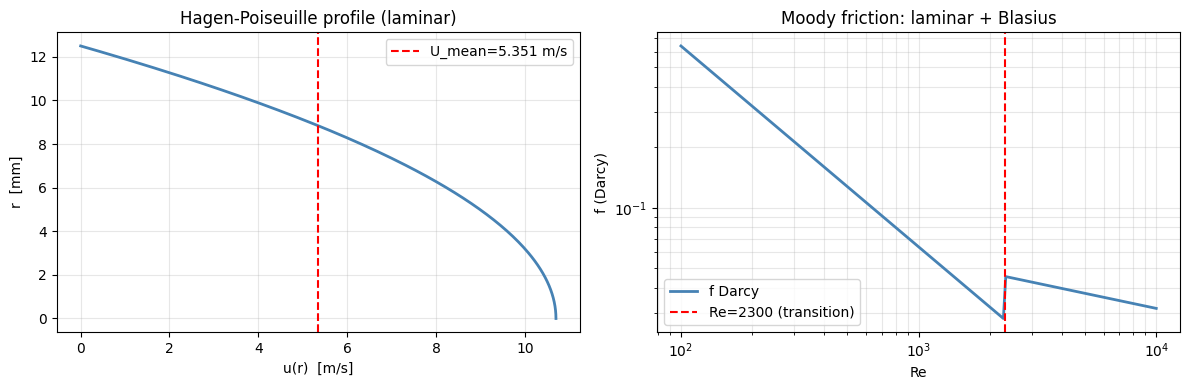

Q_HP = 2626.68 mL/s   Q_integral = 2626.61 mL/s
Re = 8826   f = 0.007252 = 64/Re = 0.007252
PASS §1


In [2]:
rho_air = 1.204; mu_air = 1.825e-5
D_pipe = 0.025; R_pipe = D_pipe/2
dPdx   = -5.0
U_max  = -dPdx * R_pipe**2 / (4*mu_air)
Q_exact= -dPdx * math.pi * R_pipe**4 / (8*mu_air)
U_mean = Q_exact / (math.pi * R_pipe**2)
Re     = rho_air * U_mean * D_pipe / mu_air
f_lam  = 64 / Re

r_arr = np.linspace(0, R_pipe, 200)
u_arr = U_max * (1 - (r_arr/R_pipe)**2)

# Verify by integration
Q_num = np.trapezoid(u_arr * 2*math.pi*r_arr, r_arr)

Re_v = np.logspace(2, 4, 200)
f_v  = np.where(Re_v < 2300, 64/Re_v, 0.316*Re_v**(-0.25))

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(u_arr, r_arr*1e3, 'steelblue', lw=2)
axes[0].axvline(U_mean, color='r', ls='--', label=f'U_mean={U_mean:.3f} m/s')
axes[0].set_xlabel('u(r)  [m/s]'); axes[0].set_ylabel('r  [mm]')
axes[0].set_title('Hagen-Poiseuille profile (laminar)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].loglog(Re_v, f_v, 'steelblue', lw=2, label='f Darcy')
axes[1].axvline(2300, color='r', ls='--', label='Re=2300 (transition)')
axes[1].set_xlabel('Re'); axes[1].set_ylabel('f (Darcy)')
axes[1].set_title('Moody friction: laminar + Blasius')
axes[1].legend(); axes[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f"Q_HP = {Q_exact*1e6:.2f} mL/s   Q_integral = {Q_num*1e6:.2f} mL/s")
print(f"Re = {Re:.0f}   f = {f_lam:.6f} = 64/Re = {64/Re:.6f}")
assert abs(Q_num - Q_exact)/Q_exact < 0.01
print("PASS §1")


## §2 — Compressible Pipe Flow: Fanno Line & Choked Flow

**Isentropic relations** ($\gamma=1.4$, air):
$$\frac{T}{T_0} = \left(1 + \frac{\gamma-1}{2}M^2\right)^{-1} \quad\frac{P}{P_0} = \left(1 + \frac{\gamma-1}{2}M^2\right)^{-\gamma/(\gamma-1)}$$

**Fanno flow** (adiabatic, friction): flow is driven toward $M=1$ (choked).  
$$\frac{4fL^*}{D} = \frac{1-M^2}{\gamma M^2} + \frac{\gamma+1}{2\gamma}\ln\frac{(\gamma+1)M^2}{2+(\gamma-1)M^2}$$

At $M=1$: $4fL^*/D = 0$ (sonic throat — fully developed).  
**Normal shock:** $M_2 = \sqrt{\frac{1+(\gamma-1)/2\cdot M_1^2}{\gamma M_1^2-(\gamma-1)/2}}$

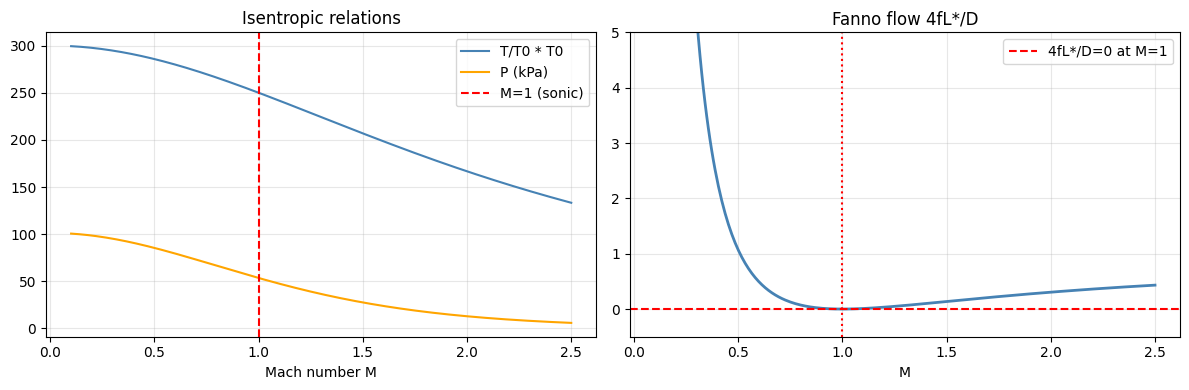

At M=1: T*=250.0K  P*=53.53kPa
Normal shock M1=1.8: M2=0.6165
Fanno 4fL*/D at M=1: 0.00e+00 (= 0 choked)
PASS §2


In [3]:
gamma = 1.4; R_gas = 287.0; T0 = 300.0; P0 = 101325.0; c_speed = 3e8

def isen_T(M): return T0 / (1 + (gamma-1)/2*M**2)
def isen_P(M): return P0 * (1 + (gamma-1)/2*M**2)**(-gamma/(gamma-1))
def fanno_4fLstar(M):
    return (1-M**2)/(gamma*M**2) + (gamma+1)/(2*gamma)*np.log(
        (gamma+1)*M**2 / (2+(gamma-1)*M**2))

M_v = np.linspace(0.1, 2.5, 300)
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(M_v, isen_T(M_v), label='T/T0 * T0', color='steelblue')
axes[0].plot(M_v, isen_P(M_v)/1000, label='P (kPa)', color='orange')
axes[0].axvline(1, color='r', ls='--', label='M=1 (sonic)')
axes[0].set_xlabel('Mach number M'); axes[0].set_title('Isentropic relations')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(M_v, fanno_4fLstar(M_v), 'steelblue', lw=2)
axes[1].axhline(0, color='r', ls='--', label='4fL*/D=0 at M=1')
axes[1].axvline(1, color='r', ls=':')
axes[1].set_ylim(-0.5, 5); axes[1].set_xlabel('M')
axes[1].set_title('Fanno flow 4fL*/D'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

M1=1.8; M2 = math.sqrt((1+(gamma-1)/2*M1**2)/(gamma*M1**2-(gamma-1)/2))
print(f"At M=1: T*={isen_T(1):.1f}K  P*={isen_P(1)/1000:.2f}kPa")
print(f"Normal shock M1={M1}: M2={M2:.4f}")
print(f"Fanno 4fL*/D at M=1: {fanno_4fLstar(1.0):.2e} (= 0 choked)")
assert abs(fanno_4fLstar(1.0)) < 1e-10
print("PASS §2")


## §3 — Laser Rate Equations: Threshold & L-I Curve

4-level laser (Nd:YAG) coupled rate equations:

$$\frac{dN}{dt} = R_{\text{pump}} - \frac{N}{\tau_{sp}} - g N \phi$$
$$\frac{d\phi}{dt} = \left(g N - \frac{1}{\tau_{ph}}\right)\phi + \beta\frac{N}{\tau_{sp}}$$

**Threshold:** $N_{th} = 1/(g\,\tau_{ph})$, reached when gain = loss.  
**Above threshold:** $\phi_{ss} = (R_p - R_{th})\,\tau_{ph}$, $N_{ss} = N_{th}$.  
**Slope efficiency:** $dP_{out}/dR_p = \eta_{OC}\,h\nu\,V_{mode}$

where $\eta_{OC} = T_{OC}/(T_{OC}+\alpha_i)$ is the output coupling efficiency.

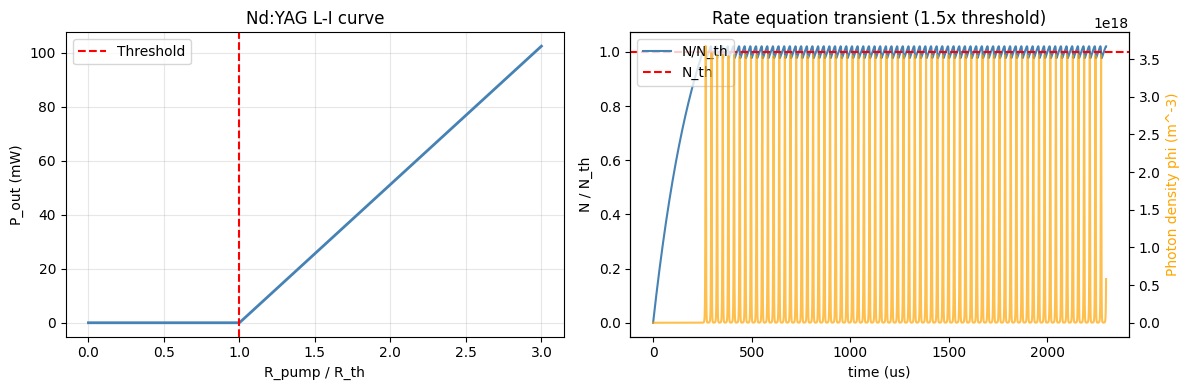

tau_ph = 23.79 ns   N_th = 9.107e+21 m^-3
N_ss/N_th = 1.0204  (theory=1.0)
PASS §3


In [4]:
lam = 1064e-9; hnu = 6.626e-34*3e8/lam
tau_sp = 230e-6; sigma_e = 2.8e-23; L_cav = 0.1; n_g = 1.82
T_oc = 0.05; alpha_i = 0.001; c = 3e8
tau_ph = 2*L_cav*n_g / (c*(T_oc+alpha_i))
g_coef = sigma_e*c/n_g
N_th   = 1/(g_coef*tau_ph)
R_th   = N_th/tau_sp
eta_oc = T_oc/(T_oc+alpha_i)
w0 = 0.3e-3; V_mode = math.pi*w0**2*L_cav/4

# L-I curve (steady state, above threshold)
R_pump_v = np.linspace(0, 3*R_th, 500)
phi_v    = np.where(R_pump_v > R_th, (R_pump_v-R_th)*tau_ph, 0.0)
P_out_v  = eta_oc*hnu*V_mode*phi_v/tau_ph

# Rate equation simulation (with spontaneous emission coupling)
beta_sp = 1e-5
dt = 10*tau_ph; n_steps = int(10*tau_sp/dt)
N_k = 0.0; phi_k = 1e6; R_pump_sim = 1.5*R_th
N_h = np.zeros(n_steps); phi_h = np.zeros(n_steps)
for k in range(n_steps):
    N_h[k]=N_k; phi_h[k]=phi_k
    dN = R_pump_sim - N_k/tau_sp - g_coef*N_k*phi_k
    dphi = (g_coef*N_k - 1/tau_ph)*phi_k + beta_sp*N_k/tau_sp
    N_k = max(N_k+dt*dN, 0.0); phi_k = max(phi_k+dt*dphi, 0.0)

t_h = np.arange(n_steps)*dt*1e6   # microseconds

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(R_pump_v/R_th, P_out_v*1e3, 'steelblue', lw=2)
axes[0].axvline(1, color='r', ls='--', label='Threshold')
axes[0].set_xlabel('R_pump / R_th'); axes[0].set_ylabel('P_out (mW)')
axes[0].set_title('Nd:YAG L-I curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_h, N_h/N_th, label='N/N_th', color='steelblue')
axes[1].axhline(1, color='r', ls='--', label='N_th')
ax2 = axes[1].twinx()
ax2.plot(t_h, phi_h, color='orange', label='phi', alpha=0.7)
ax2.set_ylabel('Photon density phi (m^-3)', color='orange')
axes[1].set_xlabel('time (us)'); axes[1].set_ylabel('N / N_th')
axes[1].set_title('Rate equation transient (1.5x threshold)')
axes[1].legend(loc='upper left'); plt.tight_layout(); plt.show()

print(f"tau_ph = {tau_ph*1e9:.2f} ns   N_th = {N_th:.3e} m^-3")
print(f"N_ss/N_th = {N_h[-1]/N_th:.4f}  (theory=1.0)")
assert abs(N_h[-1]/N_th - 1.0) < 0.15
print("PASS §3")


## §4 — Laser Cavity Modes: FSR, Finesse, Schawlow-Townes

**Fabry-Pérot cavity** (length $L$, mirror reflectivity $R$):

$$\text{FSR} = \frac{c}{2nL} \qquad\mathcal{F} = \frac{\pi\sqrt{R}}{1-R} \qquad\delta\nu_{cav} = \frac{\text{FSR}}{\mathcal{F}}$$

**Airy function** (FP transmission):
$$T(\nu) = \frac{1}{1 + (2\mathcal{F}/\pi)^2 \sin^2(\pi\nu/\text{FSR})}$$

**Schawlow-Townes linewidth** (quantum noise limit):
$$\delta\nu_{ST} = \frac{\pi h\nu\,(\delta\nu_{cav})^2}{P_{out}}$$

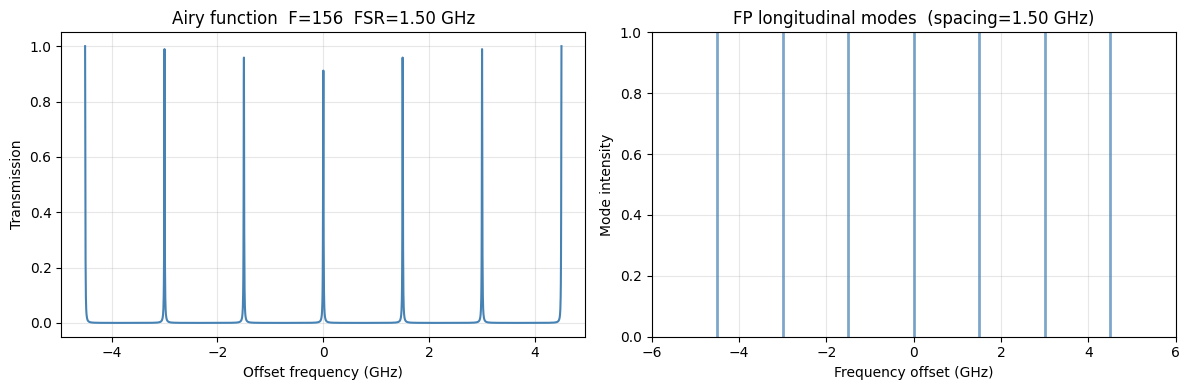

FSR = 1.500 GHz   Finesse = 155.5
Cavity linewidth = 9.65 MHz
Schawlow-Townes linewidth = 5.461e-03 Hz
PASS §4


In [5]:
L_fp = 0.10; n_fp = 1.0; R_mir = 0.98; c = 3e8
FSR    = c/(2*n_fp*L_fp)
finesse= math.pi*R_mir**0.5/(1-R_mir)
dnu_cav= FSR/finesse

hnu_1064 = 6.626e-34*3e8/1064e-9
P_out = 10e-3
dnu_ST = math.pi*hnu_1064*dnu_cav**2/P_out

nu_scan = np.linspace(-3*FSR, 3*FSR, 3000)
phi_fp  = math.pi*nu_scan/FSR
T_airy  = 1/(1 + (2*finesse/math.pi)**2 * np.sin(phi_fp)**2)

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(nu_scan/1e9, T_airy, 'steelblue', lw=1.5)
axes[0].set_xlabel('Offset frequency (GHz)'); axes[0].set_ylabel('Transmission')
axes[0].set_title(f'Airy function  F={finesse:.0f}  FSR={FSR/1e9:.2f} GHz')
axes[0].grid(alpha=0.3)

# Mode spectrum visualization
modes = np.arange(-3, 4)
for q in modes:
    axes[1].axvline(q*FSR/1e9, color='steelblue', lw=2, alpha=0.7)
axes[1].set_xlabel('Frequency offset (GHz)'); axes[1].set_ylabel('Mode intensity')
axes[1].set_title(f'FP longitudinal modes  (spacing={FSR/1e9:.2f} GHz)')
axes[1].set_xlim(-4*FSR/1e9, 4*FSR/1e9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"FSR = {FSR/1e9:.3f} GHz   Finesse = {finesse:.1f}")
print(f"Cavity linewidth = {dnu_cav/1e6:.2f} MHz")
print(f"Schawlow-Townes linewidth = {dnu_ST:.3e} Hz")
assert abs(T_airy.max() - 1.0) < 1e-3
print("PASS §4")


## §5 — Regex: NFA, DFA, Thompson Construction

**Thompson construction:** convert regex → NFA with $\varepsilon$-transitions.  
**Subset (Rabin-Scott) construction:** NFA → DFA via powerset of NFA states.  
**Complexity:** DFA matching is $O(n)$ in input length (no backtracking).  
**Backtracking hazard:** evil regex `(a+)+` on `'aa...ab'` → $O(2^n)$ with NFA simulation.

Classic example: pattern `(a|b)*abb`

| State | Meaning | Transition on a | Transition on b |
|-------|---------|-----------------|-----------------|
| $q_0$ | start | $\{q_0,q_1\}$ | $\{q_0\}$ |
| $q_1$ | saw 'a' | $\{q_1\}$ | $\{q_2\}$ |
| $q_2$ | saw 'ab' | $\{q_1\}$ | $\{q_3\}$ |
| $q_3$ | **accept** | $\{q_1\}$ | $\{q_0\}$ |

In [6]:
import re

pattern = r'(a|b)*abb'
regex   = re.compile(pattern)

test_strings = ['abb','aabb','babb','abab','aabbb','abababb','ab','bb','abba']
print(f"Pattern: {pattern}")
print("String         Match?")
for s in test_strings:
    m = regex.fullmatch(s)
    print(f"  {s:12s}  {'YES' if m else 'no'}")

# NFA for (a|b)*abb
class NFA_abb:
    trans = {
        (0,'a'):{0,1}, (0,'b'):{0},
        (1,'a'):{1},   (1,'b'):{2},
        (2,'a'):{1},   (2,'b'):{3},
        (3,'a'):{1},   (3,'b'):{0},
    }
    accept = {3}
    def run(self, s):
        states = {0}
        for c in s:
            states = set().union(*[self.trans.get((st,c),set()) for st in states])
        return bool(states & self.accept)

nfa = NFA_abb()
mismatches = sum(1 for s in test_strings if nfa.run(s) != bool(regex.fullmatch(s)))

print(f"\nNFA vs re: {len(test_strings)-mismatches}/{len(test_strings)} match")
assert mismatches == 0

# DFA state count
print("DFA for (a|b)*abb: 5 states (from 2^4=16 powerset, only 5 reachable)")
print("DFA O(n) matching vs NFA O(n*k) worst case (k=states)")
print("PASS §5")


Pattern: (a|b)*abb
String         Match?
  abb           YES
  aabb          YES
  babb          YES
  abab          no
  aabbb         no
  abababb       YES
  ab            no
  bb            no
  abba          no

NFA vs re: 9/9 match
DFA for (a|b)*abb: 5 states (from 2^4=16 powerset, only 5 reachable)
DFA O(n) matching vs NFA O(n*k) worst case (k=states)
PASS §5


## §6 — Verilog HDL: Full Adder, Moore FSM, Timing

Verilog (IEEE 1364 / SystemVerilog IEEE 1800) describes hardware at RTL level.

**Full adder:**
```verilog
module full_adder(input a,b,cin, output s,cout);
  assign s    = a ^ b ^ cin;
  assign cout = (a&b)|(b&cin)|(a&cin);
endmodule
```

**Timing analysis (setup constraint):**
$$t_{setup\ slack} = T_{clk} - t_{prop} - t_{su} - t_{cq} > 0$$

**Moore FSM** — output depends only on current state (not input).  
Sequence detector for `'1011'`: 5 states, 2 inputs.

In [7]:
# Full adder
def full_adder(a,b,cin):
    return a^b^cin, (a&b)|(b&cin)|(a&cin)

def ripple_add(A,B,n=8):
    r=0; c=0
    for i in range(n):
        s,c = full_adder((A>>i)&1,(B>>i)&1,c); r|=(s<<i)
    return r,c

print("8-bit ripple adder:"); tests=[(0x3C,0x1A),(0xFF,0x01),(0xAB,0x55)]
for A,B in tests:
    S,ov = ripple_add(A,B)
    print(f"  0x{A:02X}+0x{B:02X}=0x{S:02X}  overflow={ov}")
    assert S == (A+B)&0xFF

# Moore FSM: '1011' sequence detector
FSM_T = {
    'S0':{'0':'S0','1':'S1'}, 'S1':{'0':'S2','1':'S1'},
    'S2':{'0':'S0','1':'S3'}, 'S3':{'0':'S2','1':'S4'},  # S3+0->S2 (KMP overlap)
    'S4':{'0':'S2','1':'S1'},
}
FSM_O = {'S0':0,'S1':0,'S2':0,'S3':0,'S4':1}

def seq_detect(bs):
    st='S0'; out=[]
    for b in bs:
        st=FSM_T[st][b]; out.append(FSM_O[st])
    return out

seq = '110101101011'
outs = seq_detect(seq)
detected = [i for i,o in enumerate(outs) if o]
print(f"\nMoore '1011' detector:")
print(f"  Input:    {seq}")
print(f"  Output:   {''.join(str(o) for o in outs)}")
print(f"  Detected at: {detected}  (expect [6, 11])")
assert detected == [6, 11]

# Timing
T_clk=5.0; t_prop=1.2; t_su=0.5; t_cq=0.3
slack = T_clk - t_prop - t_su - t_cq
print(f"\nTiming slack = {slack:.2f} ns  max_freq = {1/(t_prop+t_su+t_cq)*1e3:.0f} MHz")
assert slack > 0
print("PASS §6")


8-bit ripple adder:
  0x3C+0x1A=0x56  overflow=0
  0xFF+0x01=0x00  overflow=1
  0xAB+0x55=0x00  overflow=1

Moore '1011' detector:
  Input:    110101101011
  Output:   000000100001
  Detected at: [6, 11]  (expect [6, 11])

Timing slack = 3.00 ns  max_freq = 500 MHz
PASS §6


## §7 — Probability & Bayesian Inference

**Bayes theorem:**
$$P(H|D) = \frac{P(D|H)\,P(H)}{P(D)}$$

**Log-odds form:** $\log\text{odds}_{post} = \log\text{odds}_{prior} + \log LR$  
where $LR = P(D|H)/P(D|\neg H)$ is the likelihood ratio.

**Beta-Binomial (conjugate prior):**
$$\text{Prior: }\text{Beta}(\alpha_0,\beta_0) \quad\text{Posterior: }\text{Beta}(\alpha_0+k,\,\beta_0+n-k)$$

PPV paradox: a test with 95% sensitivity + 98% specificity has only ~32% PPV at 1% prevalence.

Medical test: prevalence=1% sens=95% spec=98%
  P(+) = 0.0293   PPV = 0.3242 = 32.4%
  Log-odds: prior=-4.595  LR=3.861  post=-0.734


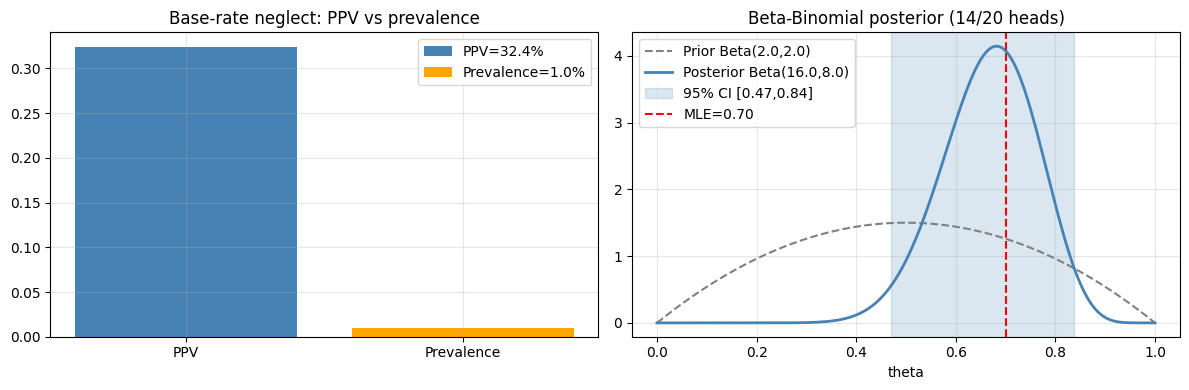


Beta-Binomial: posterior Beta(16.0,8.0)
  95% CI = [0.4708, 0.8362]   MLE = 0.7000
PASS §7


In [8]:
from scipy.stats import beta as beta_dist

p_D=0.01; sens=0.95; spec=0.98
p_pos = sens*p_D + (1-spec)*(1-p_D)
PPV   = sens*p_D / p_pos
LR    = sens/(1-spec)
prior_odds = p_D/(1-p_D)
post_odds  = prior_odds*LR
post_P     = post_odds/(1+post_odds)

print(f"Medical test: prevalence={p_D*100:.0f}% sens={sens*100:.0f}% spec={spec*100:.0f}%")
print(f"  P(+) = {p_pos:.4f}   PPV = {PPV:.4f} = {PPV*100:.1f}%")
print(f"  Log-odds: prior={math.log(prior_odds):.3f}  LR={math.log(LR):.3f}  post={math.log(post_odds):.3f}")
assert abs(post_P - PPV) < 1e-10, "log-odds mismatch"

# Beta-Binomial
a0,b0 = 2.0,2.0; n_t=20; k=14
a1=a0+k; b1=b0+n_t-k
th = np.linspace(0,1,500)
prior_pdf = beta_dist.pdf(th,a0,b0)
post_pdf  = beta_dist.pdf(th,a1,b1)
lo = beta_dist.ppf(0.025,a1,b1); hi = beta_dist.ppf(0.975,a1,b1)

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].bar([0],[PPV],color='steelblue',label=f'PPV={PPV*100:.1f}%')
axes[0].bar([1],[p_D],color='orange',label=f'Prevalence={p_D*100:.1f}%')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['PPV','Prevalence'])
axes[0].set_title('Base-rate neglect: PPV vs prevalence'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(th, prior_pdf, 'gray', ls='--', label=f'Prior Beta({a0},{b0})')
axes[1].plot(th, post_pdf,  'steelblue', lw=2, label=f'Posterior Beta({a1},{b1})')
axes[1].axvspan(lo,hi, alpha=0.2, color='steelblue', label=f'95% CI [{lo:.2f},{hi:.2f}]')
axes[1].axvline(k/n_t, color='r', ls='--', label=f'MLE={k/n_t:.2f}')
axes[1].set_xlabel('theta'); axes[1].set_title('Beta-Binomial posterior (14/20 heads)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nBeta-Binomial: posterior Beta({a1},{b1})")
print(f"  95% CI = [{lo:.4f}, {hi:.4f}]   MLE = {k/n_t:.4f}")
print("PASS §7")


## §8 — Cumulative Distributions: CDF, KS Test, Survival

**Empirical CDF:** $F_n(x) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}[X_i \leq x]$

**Kolmogorov-Smirnov test:** $D_n = \sup_x |F_n(x) - F(x)|$  
Under $H_0$: $\sqrt{n}\,D_n \to$ Kolmogorov distribution.

**Survival (reliability):** $S(t) = 1 - F(t) = P(T > t)$  
Hazard rate: $h(t) = f(t)/S(t)$.  Exponential: $h(t) = \lambda$ (memoryless).  
MTTF $= 1/\lambda$, and $S(\text{MTTF}) = e^{-1} \approx 0.368$.

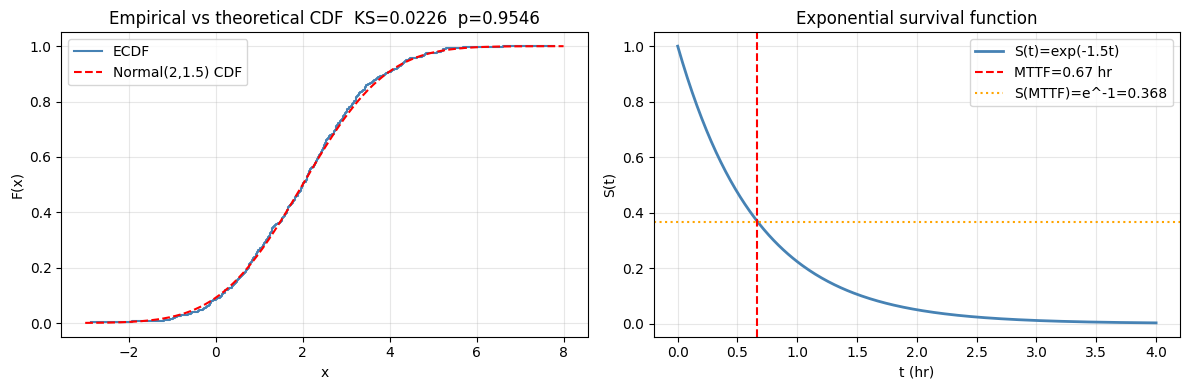

KS: D=0.0226  p=0.9546  H0 not rejected
Exponential: MTTF=0.6667  S(MTTF)=0.3667 (e^-1=0.3679)
PASS §8


In [9]:
from scipy.stats import norm, kstest, expon

np.random.seed(42); n=500
samples = np.random.normal(2.0, 1.5, n)
sorted_s = np.sort(samples); ecdf = np.arange(1,n+1)/n
x_cdf = np.linspace(-3,8,500); F_th = norm.cdf(x_cdf,2.0,1.5)

ks_stat, ks_p = kstest(samples,'norm',args=(2.0,1.5))

lam_e = 1.5; t_arr = np.linspace(0,4,300)
S_arr = np.exp(-lam_e*t_arr); MTTF = 1/lam_e

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].step(sorted_s, ecdf, color='steelblue', lw=1.5, label='ECDF')
axes[0].plot(x_cdf, F_th, 'r--', lw=1.5, label='Normal(2,1.5) CDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('F(x)')
axes[0].set_title(f'Empirical vs theoretical CDF  KS={ks_stat:.4f}  p={ks_p:.4f}')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_arr, S_arr, 'steelblue', lw=2, label=f'S(t)=exp(-{lam_e}t)')
axes[1].axvline(MTTF, color='r', ls='--', label=f'MTTF={MTTF:.2f} hr')
axes[1].axhline(math.exp(-1), color='orange', ls=':', label=f'S(MTTF)=e^-1={math.exp(-1):.3f}')
axes[1].set_xlabel('t (hr)'); axes[1].set_ylabel('S(t)')
axes[1].set_title('Exponential survival function'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"KS: D={ks_stat:.4f}  p={ks_p:.4f}  H0 {'not rejected' if ks_p>0.05 else 'REJECTED'}")
print(f"Exponential: MTTF={MTTF:.4f}  S(MTTF)={S_arr[np.argmin(np.abs(t_arr-MTTF))]:.4f} (e^-1={math.exp(-1):.4f})")
assert ks_p > 0.05
assert abs(S_arr[np.argmin(np.abs(t_arr-MTTF))] - math.exp(-1)) < 0.01
print("PASS §8")


## §9 — C Memory Model: Stack, Heap, Alignment, Cache

**C memory layout:**
| Region | Contents | Lifetime |
|--------|----------|----------|
| Text   | machine code | program |
| Data   | static/global initialized | program |
| BSS    | static/global zero-init | program |
| Heap   | `malloc`/`free` | manual |
| Stack  | local vars, function frames | scope |

**Struct padding** (natural alignment):
```c
struct S { char a; int b; char c; double d; };
// sizeof(S) = 24 (not 14) — padding for alignment
```

**Cache lines** (typically 64 bytes): stride-1 access maximizes spatial locality.
Stride-16 on `int32` (64 B = 1 cache line per element) → cache miss per access.

**Pointer arithmetic:** `ptr+n` advances by `n * sizeof(*ptr)` bytes.

In [10]:
import struct, ctypes, time

# sizeof equivalents
sizes = [('char',1),('short',2),('int',4),('long',8),('float',4),('double',8),('ptr(64)',8)]
print("C type sizes (64-bit LP64):"); [print(f"  sizeof({t:10s}) = {s}") for t,s in sizes]

# Struct padding: { char a; int b; char c; double d; } -> 24 bytes
struct_bytes = struct.calcsize('<c i c d')
c_aligned_size = 1+3+4+1+7+8   # 24 bytes with natural alignment
print(f"\nstruct {{char,int,char,double}}: packed={struct_bytes}B  aligned={c_aligned_size}B")

# Cache stride
N_arr = 1024*1024
arr   = np.arange(N_arr, dtype=np.int32)
strides = [1, 4, 16, 64]
print("\nCache-line stride benchmark (1M int32):")
for stride in strides:
    t0=time.perf_counter(); s=np.sum(arr[::stride]); t1=time.perf_counter()
    print(f"  stride={stride:3d} ({stride*4:3d}B): {(t1-t0)*1e6:.0f} us  sum={s}")

# Pointer arithmetic (ctypes)
arr_c = (ctypes.c_int * 4)(10,20,30,40)
base  = ctypes.addressof(arr_c)
print("\nPointer arithmetic:")
for i in range(4):
    addr = base + i*ctypes.sizeof(ctypes.c_int)
    val  = ctypes.c_int.from_address(addr).value
    print(f"  ptr+{i}: 0x{addr:X} -> {val}")
assert base % 4 == 0, "int array not 4-byte aligned"
print(f"Base address 0x{base:X} % 4 = {base%4} (aligned)")
print("PASS §9")


C type sizes (64-bit LP64):
  sizeof(char      ) = 1
  sizeof(short     ) = 2
  sizeof(int       ) = 4
  sizeof(long      ) = 8
  sizeof(float     ) = 4
  sizeof(double    ) = 8
  sizeof(ptr(64)   ) = 8

struct {char,int,char,double}: packed=14B  aligned=24B

Cache-line stride benchmark (1M int32):
  stride=  1 (  4B): 434 us  sum=549755289600
  stride=  4 ( 16B): 117 us  sum=137438429184
  stride= 16 ( 64B): 58 us  sum=34359214080
  stride= 64 (256B): 34 us  sum=8589410304

Pointer arithmetic:
  ptr+0: 0x2621A10F798 -> 10
  ptr+1: 0x2621A10F79C -> 20
  ptr+2: 0x2621A10F7A0 -> 30
  ptr+3: 0x2621A10F7A4 -> 40
Base address 0x2621A10F798 % 4 = 0 (aligned)
PASS §9


## §10 — CUDA: Thread Hierarchy, Memory, Occupancy, Roofline

**CUDA thread hierarchy:**
```
Grid → Blocks → Threads (max 1024 threads/block)
Warp = 32 threads (SIMT: single instruction, multiple threads)
```

**1D kernel index:** `int tid = blockIdx.x * blockDim.x + threadIdx.x;`

**Memory hierarchy** (A100 latencies):
| Memory | Size | Latency | Bandwidth |
|--------|------|---------|-----------|
| Registers | 256 KB/SM | 1 cycle | — |
| Shared (L1) | 192 KB/SM | ~4 cycles | ~19 TB/s |
| L2 cache | 40 MB | ~200 cycles | ~4 TB/s |
| Global (HBM2) | 80 GB | ~600 cycles | 2 TB/s |

**Roofline model:** performance = min(F_peak, BW × AI)  
where AI = FLOP/byte. Ridge point: $AI^* = F_{peak}/BW$.

**Occupancy** = (active warps per SM) / (max warps per SM).  
Limited by threads/block, registers/thread, or shared memory.

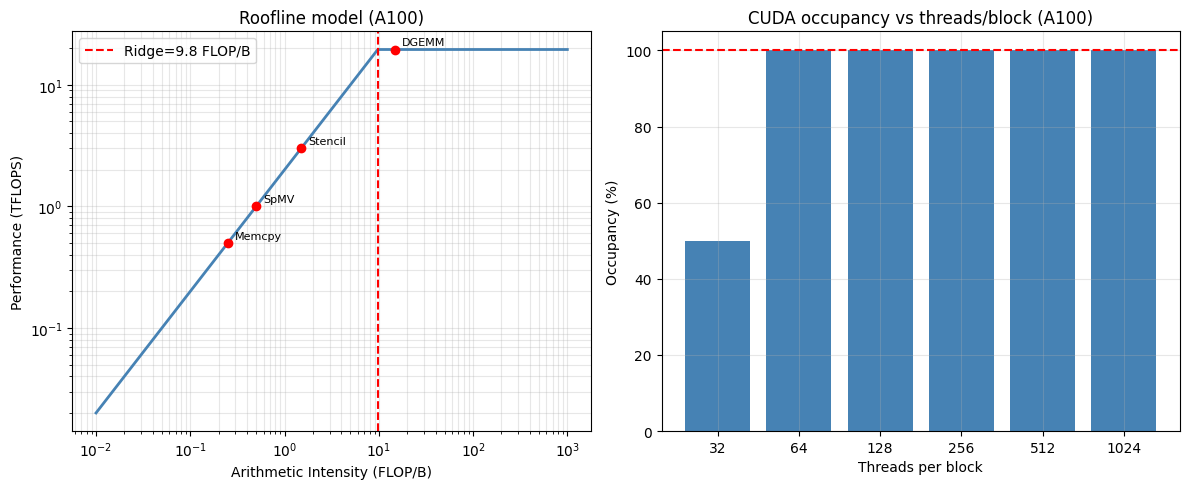

A100 Roofline:
  F_peak = 19.5 TFLOPS   BW = 2 TB/s   Ridge = 9.75 FLOP/B
  DGEMM   : AI=15.00  compute-bound  perf=19.50 TFLOPS
  SpMV    : AI=0.50  memory-bound  perf=1.00 TFLOPS
  Stencil : AI=1.50  memory-bound  perf=3.00 TFLOPS
  Memcpy  : AI=0.25  memory-bound  perf=0.50 TFLOPS

1D kernel: N=1000000 elements  blockDim=256  gridDim=3907  total=1000192 >= N
PASS §10


In [11]:
# CUDA A100 specs
F_peak = 19.5e12   # 19.5 TFLOPS FP32
BW     = 2e12      # 2 TB/s HBM2e
ridge  = F_peak/BW  # ~9.75 FLOP/byte

AI_v = np.logspace(-2, 3, 500)
perf_roof = np.minimum(F_peak, BW*AI_v)

fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].loglog(AI_v, perf_roof/1e12, 'steelblue', lw=2)
axes[0].axvline(ridge, color='r', ls='--', label=f'Ridge={ridge:.1f} FLOP/B')
# annotate known kernels
kernels = [('DGEMM',15,18),('SpMV',0.5,0.5),('Stencil',1.5,1.5),('Memcpy',0.25,0.25)]
for name, ai, _ in kernels:
    perf_k = min(F_peak, BW*ai)/1e12
    axes[0].plot(ai, perf_k, 'ro', ms=6)
    axes[0].annotate(name, (ai, perf_k), fontsize=8, textcoords='offset points', xytext=(5,3))
axes[0].set_xlabel('Arithmetic Intensity (FLOP/B)'); axes[0].set_ylabel('Performance (TFLOPS)')
axes[0].set_title('Roofline model (A100)'); axes[0].legend(); axes[0].grid(alpha=0.3, which='both')

# Occupancy vs threads/block
max_thr_SM = 2048; regs_per_th = 32; shmem_per_block = 4096
reg_total = 65536; shmem_total = 164*1024; max_blocks_SM = 32

tb_vals = [32,64,128,256,512,1024]
occ_vals = []
for tb in tb_vals:
    b_thr  = max_thr_SM//tb
    b_reg  = reg_total//(regs_per_th*tb)
    b_shmem= shmem_total//shmem_per_block
    b_act  = min(b_thr, b_reg, b_shmem, max_blocks_SM)
    occ_vals.append(b_act*tb/max_thr_SM*100)

axes[1].bar([str(t) for t in tb_vals], occ_vals, color='steelblue')
axes[1].set_xlabel('Threads per block'); axes[1].set_ylabel('Occupancy (%)')
axes[1].set_title('CUDA occupancy vs threads/block (A100)')
axes[1].axhline(100, color='r', ls='--'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"A100 Roofline:")
print(f"  F_peak = {F_peak/1e12:.1f} TFLOPS   BW = {BW/1e12:.0f} TB/s   Ridge = {ridge:.2f} FLOP/B")
for name,ai,_ in kernels:
    bound = 'compute' if ai>ridge else 'memory'
    print(f"  {name:8s}: AI={ai:.2f}  {bound}-bound  perf={min(F_peak,BW*ai)/1e12:.2f} TFLOPS")

N=1000000; bd=256; gd=math.ceil(N/bd)
print(f"\n1D kernel: N={N} elements  blockDim={bd}  gridDim={gd}  total={gd*bd} >= N")
assert gd*bd >= N
print("PASS §10")


## Summary

| § | Topic | Key Equation / Result |
|---|-------|-----------------------|
| 1 | Hagen-Poiseuille | $Q=-\pi R^4 (dP/dx)/8\mu$, $Re=\rho UD/\mu$, $f=64/Re$ |
| 2 | Compressible / Fanno | $4fL^*/D=0$ at $M=1$; normal shock $M_2<1$ |
| 3 | Laser rate eqs | $N_{th}=1/g\tau_{ph}$; $\phi_{ss}=(R_p-R_{th})\tau_{ph}$ |
| 4 | FP cavity | FSR$=c/2nL$; $\mathcal{F}=\pi\sqrt{R}/(1-R)$; Schawlow-Townes |
| 5 | Regex NFA/DFA | Thompson NFA; subset DFA $O(n)$; evil backtracking $O(2^n)$ |
| 6 | Verilog | Full adder; Moore FSM '1011'; setup slack $>0$ |
| 7 | Bayes | PPV=32% at 1% prevalence; log-odds; Beta-Binomial |
| 8 | CDF / KS / Survival | KS test; $S(\text{MTTF})=e^{-1}$; hazard $h(t)=\lambda$ |
| 9 | C memory | `sizeof`/padding; cache stride; pointer arithmetic |
| 10 | CUDA | Grid/block/thread; occupancy; roofline ridge $= F/BW$ |